In [22]:
%matplotlib widget
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

from datetime import datetime

import Flexivan_Prediction_Package

In [ ]:
# Get filenames from folder
print('Getting PAST raw data filenames...')
DATA_Folder = '/root/Flexivan/Flexivan/Daily prediction/DATA'

FILENAMES = [f for f in os.listdir(DATA_Folder) if os.path.isfile(os.path.join(DATA_Folder, f))]
selected = "Latest_Test_"
selected2 = '_DETAILED'
FILENAMES = [f for f in FILENAMES if selected in f and selected2 not in f]
DATES = Flexivan_Prediction_Package.extract_datetimes_from_filenames(FILENAMES)
Filenames_DF = pd.DataFrame({
    "Filenames": FILENAMES,
    "Dates": DATES
})
Filenames_DF_Sorted = Filenames_DF.sort_values(by='Dates')
FILENAMES = list(Filenames_DF_Sorted['Filenames'])
DATES = list(Filenames_DF_Sorted['Dates'])

print(f'DONE - {len(FILENAMES)} Filenames were found')

#endregion


Getting PAST raw data filenames...
DONE - 250 Filenames were found


In [15]:
#   Check the return dates in files relative to file's date

Pickup_LOT_Field_Name = 'CHS Pickup Loc'
Return_LOT_Field_Name = 'CHS Return Loc'
Sorting_Field='CHS Pickup Date'
Columns_2_Drop_From_Training = ['CHS ID', 'CTR Trip Id', 'CHS Return Dt', 'CHS Pickup Date', 'CTR pick Dt', 'CTR Return Dt']
Enumerated_Columns_LIST = ['CHS Pickup Loc', 'CHS Return Loc', 'CHS pickup MCO', 'CTR Trip MCO', 'O Customer', 'Customer', 'DC Loc', 'CTR Pickup Term', 'CTR Return Term', 
                           'pgkey', 'CTR Trip Loc Type Pattern', 'CTR Trip Pattern']

Return_Dates_Diff_From_Filename_Date = []           # in hours. The return date is subtracted from filename date.

for file_index, filename in enumerate(FILENAMES):
    print(f'Reading file No.{file_index+1} out of {len(FILENAMES)}...', end='\r')
    File_Analysis_Results_OBJ = Flexivan_Prediction_Package.File_Analysis_Reults(f'{DATA_Folder}/{filename}', Sorting_Field, Columns_2_Drop_From_Training, Enumerated_Columns_LIST)

    filename_date = Flexivan_Prediction_Package.extract_datetimes_from_filenames([filename])[0]     # There is only on date in list
    Return_Dates = list(File_Analysis_Results_OBJ.DATA['CTR Return Dt'].unique())

    for return_date in Return_Dates:
        try:
            diff = filename_date - datetime.strptime(return_date, '%Y-%m-%d %H:%M:%S')
        except:
            diff = filename_date - datetime.strptime(return_date, '%Y-%m-%d %H:%M:%S.%f')

        hours = diff.total_seconds() / 3600

        Return_Dates_Diff_From_Filename_Date.append(hours)


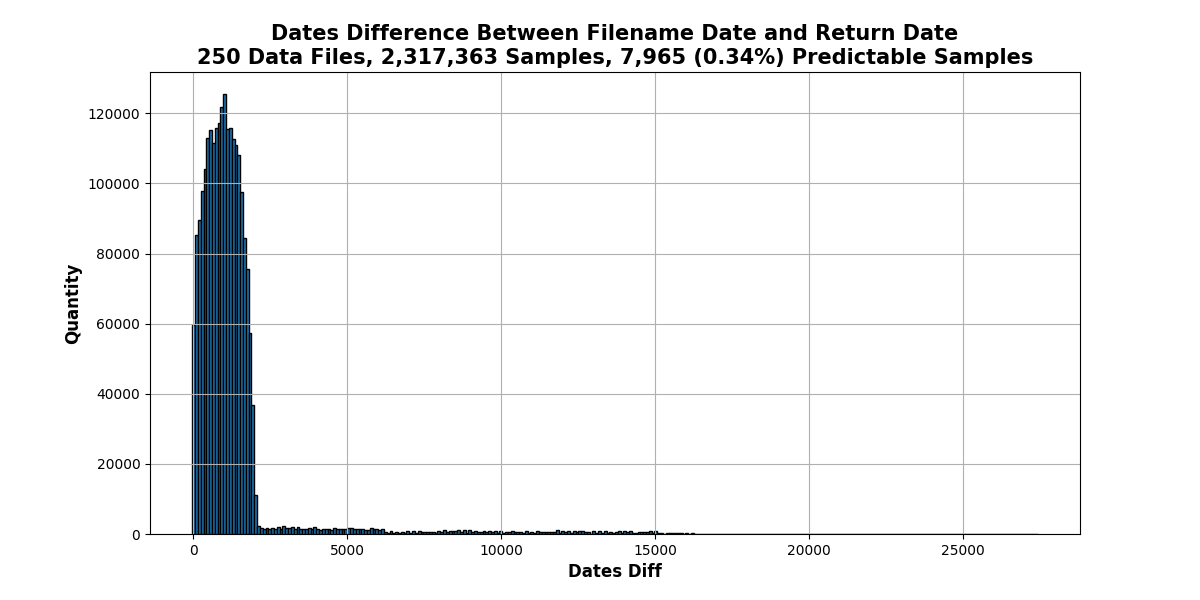

In [54]:
# Display results historgram

Samples_No = len(Return_Dates_Diff_From_Filename_Date)
Samples_No_STR = Flexivan_Prediction_Package.Comma_Separation_Num_String(Samples_No)

negatives = [x for x in Return_Dates_Diff_From_Filename_Date if x < 0]

plt.figure(figsize=(12,6))
plt.hist(Return_Dates_Diff_From_Filename_Date, bins=300, edgecolor='black')
plt.xlabel('Dates Diff', fontsize=12, fontweight='bold')
plt.ylabel('Quantity', fontsize=12, fontweight='bold')
plt.title(f'Dates Difference Between Filename Date and Return Date\n{len(FILENAMES)} Data Files, {Samples_No_STR} Samples, {Flexivan_Prediction_Package.Comma_Separation_Num_String(len(negatives))} ({np.round(100*len(negatives)/Samples_No, 2)}%) Predictable Samples', fontweight='bold', fontsize=15)
plt.grid()
plt.show()